In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn import metrics

# Primera visita a Análisis de Componentes Principales

+ En las sesiones de pizarrón ya vimos las ideas detrás del PCA.

+ El **Análisis de Componentes Principales** (Principal Component Analysis, PCA) es una técnica de reducción de dimensionalidad... i.e. pasar de muchas columnas a idealmente menos columnas. O bien, quitar información redundante.

+ ¿Qué hace? Transforma un conjunto de datos de posibles variables **posiblemente correlacionadas** en un nuevo conjunto de variables **no correlacionadas**

+ La nuevas variables se conocen como **componentes principales**, i.e. son variables que no están correlacionadas.

+ Esta transformación, no es una transformación cualquiera. De hecho, intenta conservar la mayor cantidad de información (varianza) posible, i.e. intenta que la variabilidad del conjunto de datos original se conserve lo más posible en el "nuevo" dataset.

+ Lo que está suponiendo es que en la información con gran variabilidad está la ''carnita'' de la información, i.e. lo más importante.

+ Imagina que tienes un conjunto de datos en 3D, pero la mayor variación se encuentra sobre un plano inclinado incrustado en ese espacio 3D.

+ PCA intenta identificar ese plano y permite "aplanar" los datos sobre él, i.e. reduce a 2D pero conservando la estructura principal.

+ Los componentes principales son combinaciones lineales de las variables originales.

+ Si $$X_1, X_2,\ldots, X_p$$ son las variables originales (i.e. las columnas originales), entonces cada componente principal es de la forma
$$CP_j = \phi_{j,1}X_1 + \phi_{j,2}X_2 + \ldots + \phi_{j,p}X_p,$$
donde los $\phi$'s son las ponderaciones de dicha combinación lineal

+ Formalmente si hay $p$ variables, habrá $p$ componentes principales..... PEEERO buscamos que con menos componentes principales, se logre "atrapar" mucha de la variablidad del dataset original.

+ Es decir, me quedaré con
$$CP_1,CP_2,\ldots, CP_k$$ donde $k<p$. Esto es precisamente esto la reducción de dimensionalidad.

+  **RESULTADO MATEMÁTICO:** Las componentes principales son los eigenvectores de la matriz de covarianzas.


In [2]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion17/decathon_data.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [3]:
df.head()

,name,x100m,long_jump,shot_put,high_jump,x400m,x110m_hurdle,discus,pole_vault,javeline,x1500m,rank,points,competition
0,SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217,Decastar
1,CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122,Decastar
2,BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067,Decastar
3,YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4,5,8036,Decastar
4,ZSIVOCZKY,11.13,7.30,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268.0,7,8004,Decastar


+ Los datos que trabajaremos son del decatlón. Competencia atlética combinada de 10 pruebas que se lleva a cabo en dos días consecutivos:

1. 100 metros planos
2. Salto de longitud
3. Lanzamiento de peso
4. Salto de altura
5. 400 metros planos
6. 110 metros con obstáculos
7. Lanzamiento de disco
8. Salto con garrocha
9. Lanzamiento de jabalina
10. 1500 metros lisos

In [4]:
df = df.set_index('name')

In [5]:
df.head()

,x100m,long_jump,shot_put,high_jump,x400m,x110m_hurdle,discus,pole_vault,javeline,x1500m,rank,points,competition
name,,,,,,,,,,,,,
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7,1,8217,Decastar
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5,2,8122,Decastar
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1,4,8067,Decastar
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4,5,8036,Decastar
ZSIVOCZKY,11.13,7.30,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268.0,7,8004,Decastar


In [6]:
df_grafico = pd.read_csv(url)
fig = px.scatter(df_grafico,
                 x = "rank",
                 y = "points",
                 facet_col = "competition",
                 text = "name",
                 title = "Puntos vs ranking",
                 template = "plotly_white")

# Ajustar posición de etiquetas para que no tapen el punto
fig.update_traces(textposition = 'top center')

fig.show()

In [7]:
# Sólo se considerarán los puntajes de las disciplinas del decatlón
variables_consideradas = ['x100m', 'long_jump', 'shot_put', 'high_jump', 'x400m',
                         'x110m_hurdle', 'discus', 'pole_vault', 'javeline', 'x1500m']

In [8]:
X = df[variables_consideradas]

In [9]:
X.head()

,x100m,long_jump,shot_put,high_jump,x400m,x110m_hurdle,discus,pole_vault,javeline,x1500m
name,,,,,,,,,,
SEBRLE,11.04,7.58,14.83,2.07,49.81,14.69,43.75,5.02,63.19,291.7
CLAY,10.76,7.40,14.26,1.86,49.37,14.05,50.72,4.92,60.15,301.5
BERNARD,11.02,7.23,14.25,1.92,48.93,14.99,40.87,5.32,62.77,280.1
YURKOV,11.34,7.09,15.19,2.10,50.42,15.31,46.26,4.72,63.44,276.4
ZSIVOCZKY,11.13,7.30,13.48,2.01,48.62,14.17,45.67,4.42,55.37,268.0


+ Entendamos la estructura de correlación de los datos originales

In [10]:
# Se obtiene la matriz de correlación
matriz_correlacion = X.corr()
matriz_correlacion

,x100m,long_jump,shot_put,high_jump,x400m,x110m_hurdle,discus,pole_vault,javeline,x1500m
x100m,1.000000,-0.737793,-0.370318,-0.314649,0.570345,0.669979,-0.389376,0.011564,-0.266355,-0.178053
long_jump,-0.737793,1.000000,0.373785,0.268208,-0.503669,-0.552116,0.328765,0.079820,0.288068,0.173326
shot_put,-0.370318,0.373785,1.000000,0.574800,-0.207359,-0.270163,0.722518,-0.068371,0.475586,0.009596
high_jump,-0.314649,0.268208,0.574800,1.000000,-0.261660,-0.202258,0.421019,-0.551296,0.210518,-0.156990
x400m,0.570345,-0.503669,-0.207359,-0.261660,1.000000,0.597014,-0.254533,0.111569,0.023506,0.183460
x110m_hurdle,0.669979,-0.552116,-0.270163,-0.202258,0.597014,1.000000,-0.421361,0.121187,0.096558,-0.103313
discus,-0.389376,0.328765,0.722518,0.421019,-0.254533,-0.421361,1.000000,-0.260968,0.263918,0.185435
pole_vault,0.011564,0.079820,-0.068371,-0.551296,0.111569,0.121187,-0.260968,1.000000,0.135368,0.315778
javeline,-0.266355,0.288068,0.475586,0.210518,0.023506,0.096558,0.263918,0.135368,1.000000,-0.044750
x1500m,-0.178053,0.173326,0.009596,-0.156990,0.183460,-0.103313,0.185435,0.315778,-0.044750,1.000000


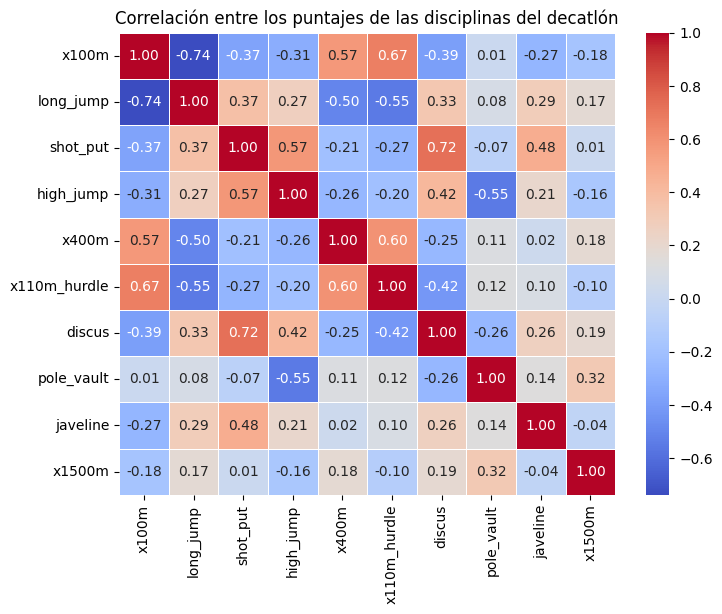

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion,
    annot = True,       # Imprime los valores numéricos de las correlaciones
    cmap = "coolwarm",  # Se le establece una paleta de colores
    fmt = ".2f",        # Formato para las anotaciones a 2 cifras decimales
    linewidths = 0.5    # Agrega una pequeña línea entre los cuadritos
)
plt.title('Correlación entre los puntajes de las disciplinas del decatlón')
plt.show()

+ Como hicimos en el caso de clustering, se deben escarlar las variables para que sean comparables entre sí (i.e. que esten en la misma escala)

In [12]:
# Se define el objeto Scaler
scaler = StandardScaler()
# Se escala el dataset
X_scaled = scaler.fit_transform(X)

df_escalado = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
df_escalado.head()

,x100m,long_jump,shot_put,high_jump,x400m,x110m_hurdle,discus,pole_vault,javeline,x1500m
name,,,,,,,,,,
SEBRLE,0.172851,0.744915,0.349261,0.765931,0.522924,0.419023,-0.325788,0.721385,0.949125,1.316061
CLAY,-0.840137,0.121802,-0.345200,-1.472641,0.064110,-0.968087,1.742003,0.330272,0.356923,2.294591
BERNARD,0.100495,-0.466694,-0.357383,-0.833049,-0.394703,1.069231,-1.180198,1.894721,0.867307,0.157800
YURKOV,1.258196,-0.951337,0.787867,1.085727,1.159006,1.762786,0.418854,-0.451952,0.997825,-0.211645
ZSIVOCZKY,0.498454,-0.224372,-1.295514,0.126339,-0.717958,-0.708004,0.243819,-1.625288,-0.574237,-1.050386


## Aplicación de la función PCA de Python

+ La sintaxis es intuitiva y natural como hemos visto hasta el momento

In [13]:
# Se le dice a Python que haré un PCA
pca = PCA()
pca

PCA()

In [14]:
# Se entrena el modelo
pca_features = pca.fit_transform(X_scaled)

# Convertimos a DataFrame para facilitar la lectura
pca_df = pd.DataFrame(
    data = pca_features,
    columns = [f'PC{i+1}' for i in range(pca_features.shape[1])],
    index = X.index
)

In [15]:
pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
name,,,,,,,,,,
SEBRLE,-0.277958,0.536434,1.585239,0.105823,-1.074623,0.731398,-0.050296,0.030474,0.642808,-0.078759
CLAY,-0.904854,2.094280,0.840685,1.850718,0.408645,-1.532637,-0.774155,-0.066611,-0.060335,-0.161136
BERNARD,1.372266,1.348116,0.961932,-1.493072,0.182667,0.611043,-0.764614,-0.505153,-0.076263,0.033512
YURKOV,0.928205,-2.281744,1.942688,0.096823,-0.190927,0.382596,-0.301288,0.095101,0.068987,-0.140543
ZSIVOCZKY,0.103817,-1.089822,-2.098908,0.071906,0.032938,-0.949900,-0.313379,0.300383,0.489713,-0.450773
McMULLEN,-0.239858,-0.939092,-0.818136,1.201893,-1.830199,-0.330364,0.029516,-0.543750,-0.052143,-0.383266
MARTINEAU,2.537291,-1.801094,0.051975,0.374306,2.285411,0.242875,0.357093,0.439548,-0.115445,-0.680200
HERNU,1.902843,0.330277,1.288682,0.766505,-0.239465,-0.559786,0.604322,1.762795,0.046912,0.402201
BARRAS,1.805625,-0.302590,-0.592810,0.656526,0.244039,-0.094378,-0.282829,-0.511376,0.698396,0.493839


¿Se acuerdan que dijimos que las nuevas variables (a.k.a. las componentes pricipales) estaban no correlacionadas?

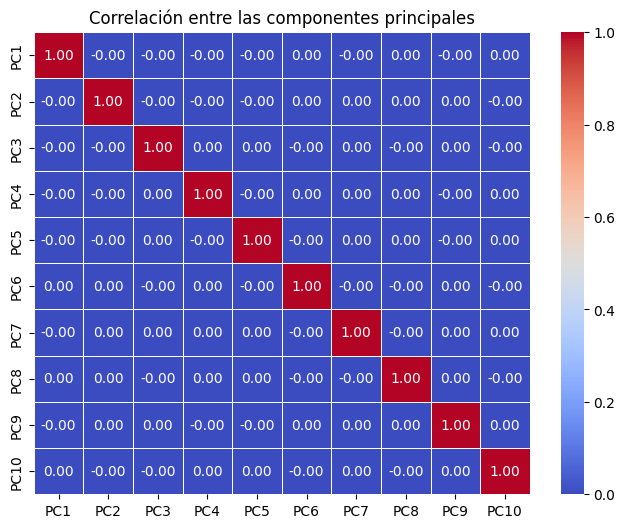

In [16]:
matriz_correlacion_pca = pca_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_correlacion_pca,
    annot = True,       # Imprime los valores numéricos de las correlaciones
    cmap = "coolwarm",  # Se le establece una paleta de colores
    fmt = ".2f",        # Formato para las anotaciones a 2 cifras decimales
    linewidths = 0.5    # Agrega una pequeña línea entre los cuadritos
)
plt.title('Correlación entre las componentes principales')
plt.show()

Un PCA no sirve de nada si no se sabe cuánta información se retuvo.

+ Varianza explicada: ¿Qué porcentaje de la "información" total capturan la $k$-ésima componente principal?

+ Cargas (Loadings): ¿Qué pruebas físicas de decatlón influyen más en cada componente?

Recuerden que un componente principal es de la forma
$$CP_j = \phi_{j,1}X_1 + \phi_{j,2}X_2 + \ldots + \phi_{j,p}X_p,$$
donde los $\phi$'s son las ponderaciones de dicha combinación lineal

+ Los loadings son precisamente todos esos $\phi$'s

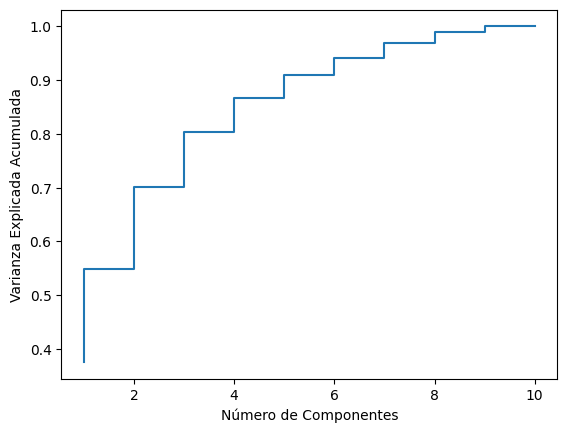

In [17]:
# Varianza explicada acumulada
varianza_explicada_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.step(range(1, len(varianza_explicada_acumulada) + 1), varianza_explicada_acumulada)
plt.ylabel('Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes')
plt.show()

+ Un **biplot** es una visualización que combina en un mismo plano dos elementos:

  + La dispersión de las observaciones (renglones) mediante puntos
  + La contribución de las variables originales (columnas) mediante vectores.

+ Permite observar simultáneamente qué observaciones son "similares" y qué variables impulsan esa agrupación.

+ El término "bi" en la palabra biplot viene de que se quiere representar tanto observaciones individuales (renglones) y variables (columnas)juntos.

+ Se grafica usando **sólo las primeras dos componentes principales (PC1 y PC2)**, que (idealmente) capturan la mayor variabilidad de los datos.

  + Vectores (variables): La longitud de la flecha indica la importancia de la variable en el componente, y la dirección indica la relación entre variables (ángulos pequeños indican correlación positiva).

  + Puntos (observaciones): Puntos cercanos en el gráfico son similares en sus características originales.

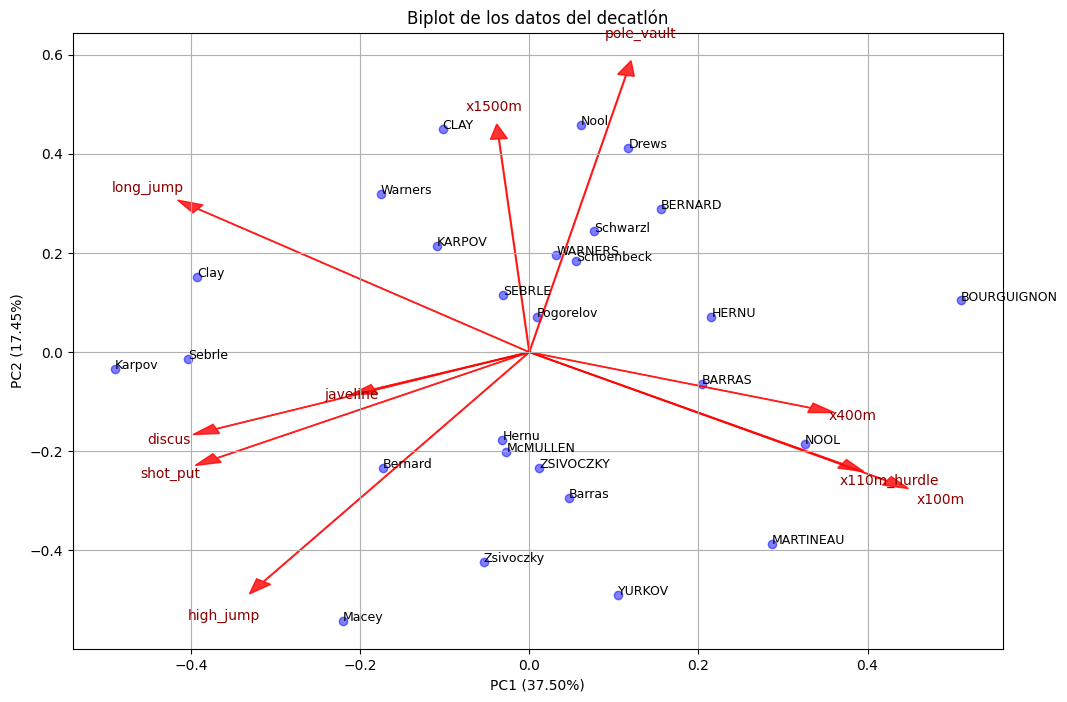

In [18]:
def biplot(score, coeff, labels=None, index_labels=None):
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]
    scalex = 1.0/(xs.max() - xs.min())
    scaley = 1.0/(ys.max() - ys.min())

    plt.figure(figsize=(12, 8))

    # Dibujar los puntos (Atletas)
    plt.scatter(xs * scalex, ys * scaley, c='blue', alpha=0.5)

    # Añadir etiquetas de los atletas
    if index_labels is not None:
        for i, txt in enumerate(index_labels):
            plt.annotate(txt, (xs[i] * scalex, ys[i] * scaley), fontsize=9)

    # Dibujar los vectores (Pruebas)
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1], color='red', alpha=0.8, head_width=0.02)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color='g', ha='center', va='center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color='darkred', ha='center', va='center')

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%})")
    plt.grid()

# Llamada a la función
biplot(pca_features[:,0:2], np.transpose(pca.components_[0:2, :]), labels=X.columns, index_labels=X.index)
plt.title('Biplot de los datos del decatlón')
plt.show()

En este caso, el biplot representa el 37.50 + 17.45 = 54.95 por ciento de la variabilidad total del dataset original

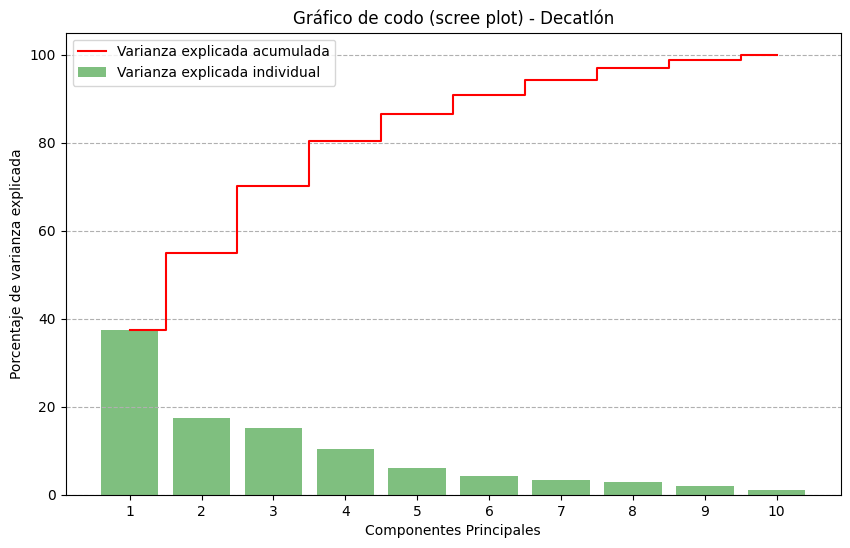

In [19]:
# Calculamos la varianza explicada por cada componente
exp_var = pca.explained_variance_ratio_ * 100
exp_var_cum = np.cumsum(exp_var)

plt.figure(figsize=(10, 6))

# Barras para la varianza de cada componente
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center',
        label='Varianza explicada individual', color='g')

# Línea para la varianza acumulada
plt.step(range(1, len(exp_var_cum) + 1), exp_var_cum, where='mid',
         label='Varianza explicada acumulada', color='red')

plt.ylabel('Porcentaje de varianza explicada')
plt.xlabel('Componentes Principales')
plt.title('Gráfico de codo (scree plot) - Decatlón')
plt.xticks(range(1, 11))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--')
plt.show()

+ A criterio de la *developer*, seleccionará tantas componentes principales como variabilidad esté dispuesta a perder.

+ A "ojo", con 4 componentes principales logramos "atrapar" el 80\% de la variabilidad de los datos.

+ Si se eligen los $k$ primeros eigenvectores, se forma una matriz de proyección
$$W_k = [CP_1 | CP_2 | \cdots | CP_k]$$

+ Para transformar los datos al nuevo espacio PCA
$$Z = XW_k$$
donde $Z$ es el nuevo conjunto de datos en un espacio reducido y $X$ es el conjunto de datos originales escalado, i.e.
$$X = [X_1 | X_2 | \ldots | X_p]$$
escalados

## ¿Cómo medimos qué tan buena es la representación?

+ Una métrica para ver qué tan buena es la representación es el "coseno cuadrado"

+ $cos^2$ es la abreviatura de coseno al cuadrado del ángulo entre el vector de una variable o una observación, y el eje de un componente principal

+ Sirve para medir qué tan bien está representado un individuo o una variable en un componente determinado.

+ **Importante:** La calidad de la representación se mide diferente para variables (columnas) que para observaciones (renglones).

+ Las variables se miden por su correlación, mientras que las observaciones se miden por su distancia.

+ Supóngase que se tiene una observación $i$, y sus coordenadas sobre los primeros $k$ componentes son $$z_{i1}, z_{i2}, \ldots, z_{ik}$$

La distancia euclidiana al origen es
$$||z_i||^2 = z_{i1}^2 + z_{i2}^2 + \ldots + z_{ik}^2$$

Entonces, el $cos^2$ del individuo $i$ en el componente $j$ es
$$cos^2(i,j) = \frac{z_{ij}^2}{||z_i||^2}$$

+ Esto responde a la pregunta ¿Qué tanto de la posición del punto está explicado por este componente?

+ Para una variable $x_j$, su correlación con el componente $PC_k$ es
$$corr(x_j, PC_k) = cos(\theta)$$
entonces
$$cos^2(\theta) = corr^2(x_j, PC_k)$$
+ Esto mide qué tanto contribuye una variable a un componente principal

- $cos^2$ cercano a 1, significa que el componente explica muy bien al punto o variable

- $cos^2$ cercano a 0, significa que el componente no explica mucho a ese punto o variable

+ Es común usar lo que se conoce como **círculo de correlación**, en donde el $cos^2$ indica cuáles variables están bien representadas por los componentes (las que están cerca del borde del círculo lo están mejor).


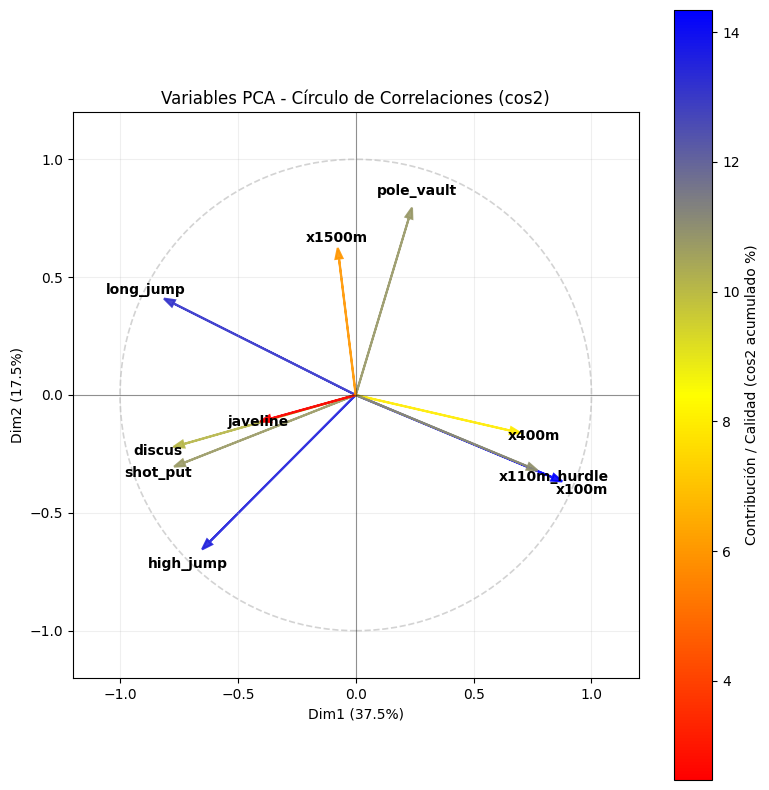

In [20]:
# Cálculos base
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
cos2 = loadings**2
contrib_plano = (cos2[:, :2].sum(axis=1) / np.sum(cos2[:, :2])) * 100

# Creamos la figura y el eje explícito (ax)
fig, ax = plt.subplots(figsize=(8, 8))

# Forzamos que la escala física de X e Y sea idéntica
ax.set_aspect('equal', adjustable='box')

# Dibujamos el círculo unitario de referencia (radio = 1)
circulo = plt.Circle((0,0), 1, color='lightgray', fill=False, linestyle='--', linewidth=1.2)
ax.add_artist(circulo)

# Definimos el gradiente de color (Blue -> Green -> Red)
cmap_custom = LinearSegmentedColormap.from_list("fviz_gradient", ["red", "yellow", "blue"])
norm = plt.Normalize(vmin=contrib_plano.min(), vmax=contrib_plano.max())

# Dibujamos las flechas y etiquetas
for i in range(loadings.shape[0]):
    # Color según contribución
    color = cmap_custom(norm(contrib_plano[i]))

    # Flecha (usamos ax.arrow para control preciso)
    ax.arrow(0, 0, loadings[i, 0], loadings[i, 1],
              color=color, alpha=0.9, head_width=0.03, linewidth=1.5)

    # Etiqueta (un 15% más allá de la punta de la flecha)
    ax.text(loadings[i, 0] * 1.15, loadings[i, 1] * 1.15,
             X.columns[i], color='black', ha='center', va='center', fontweight='bold', fontsize=10)

# Ajustes de ejes y estética
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.4)

# Etiquetas de varianza explicada (Dinámicas)
ax.set_xlabel(f'Dim1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'Dim2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Variables PCA - Círculo de Correlaciones (cos2)')

# Añadimos la barra de color
sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm)
fig.colorbar(sm, ax=ax, label='Contribución / Calidad (cos2 acumulado %)')

ax.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()

+ Cuando graficamos variables, estamos representando la correlación de cada prueba (ej. 100m, Salto, disco) con las componentes principales.

+ Como una correlación nunca puede ser mayor a 1 ni menor a -1, todas las variables están "atrapadas" dentro de una esfera de radio 1. El borde del círculo representa el 100% de la información explicada.

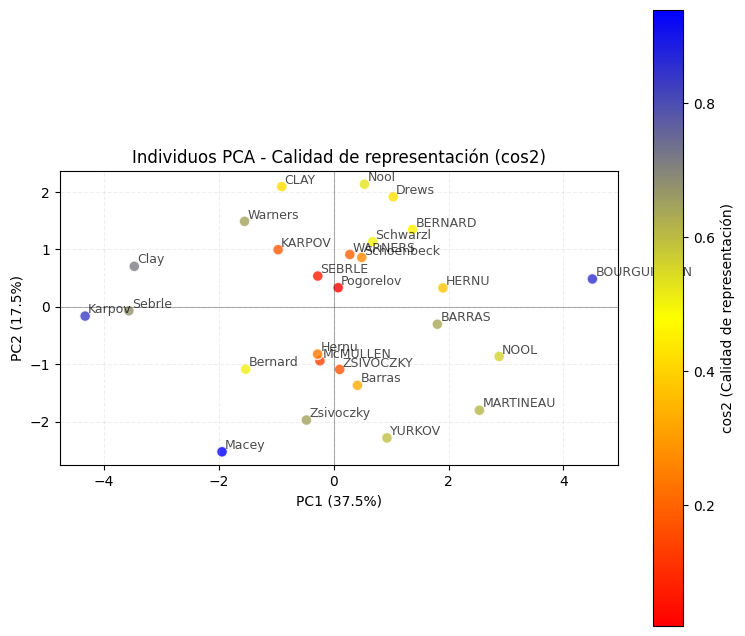

In [21]:
# Cálculo del cos2 para los individuos
# El cos2 de un individuo es el cuadrado de su coordenada dividido entre
# la distancia al cuadrado del individuo al origen (en el espacio total)
# Una forma práctica: (coordenadas^2) / suma(coordenadas^2 de todos los componentes)
coords_ind = pca_features[:, :2] # PC1 y PC2
dist_total_sq = np.sum(pca_features**2, axis=1)
cos2_ind = np.sum(coords_ind**2, axis=1) / dist_total_sq

# 2. Configuración del gráfico
fig, ax = plt.subplots(figsize=(9, 8))

# Forzamos proporción igualitaria para evitar deformación
ax.set_aspect('equal', adjustable='box')

# 3. Definir el gradiente (Blue -> Green -> Red)
cmap_custom = LinearSegmentedColormap.from_list("fviz_ind", ["red", "yellow", "blue"])
norm = plt.Normalize(vmin=cos2_ind.min(), vmax=cos2_ind.max())

# 4. Graficar los puntos (Atletas)
scatter = ax.scatter(coords_ind[:, 0], coords_ind[:, 1],
                     c=cos2_ind, cmap=cmap_custom, norm=norm,
                     s=60, edgecolors='w', alpha=0.8)

# 5. Añadir etiquetas de los nombres de los atletas
for i, txt in enumerate(X.index):
    ax.text(coords_ind[i, 0] + 0.05, coords_ind[i, 1] + 0.05,
            txt, fontsize=9, alpha=0.7)

# 6. Estética y ejes
ax.axhline(0, color='black', lw=0.8, alpha=0.3)
ax.axvline(0, color='black', lw=0.8, alpha=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Individuos PCA - Calidad de representación (cos2)')

# Añadir Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm)
fig.colorbar(sm, ax=ax, label='cos2 (Calidad de representación)')

plt.grid(True, alpha=0.2, linestyle='--')
plt.show()

+ Los puntos representan a los atletas (puntuaciones o scores).

+ Estas puntuaciones no son correlaciones; son combinaciones lineales de sus resultados reales.

+ No hay un límite teórico de "1" para un atleta; un atleta excepcional aparecería muy lejos del origen.

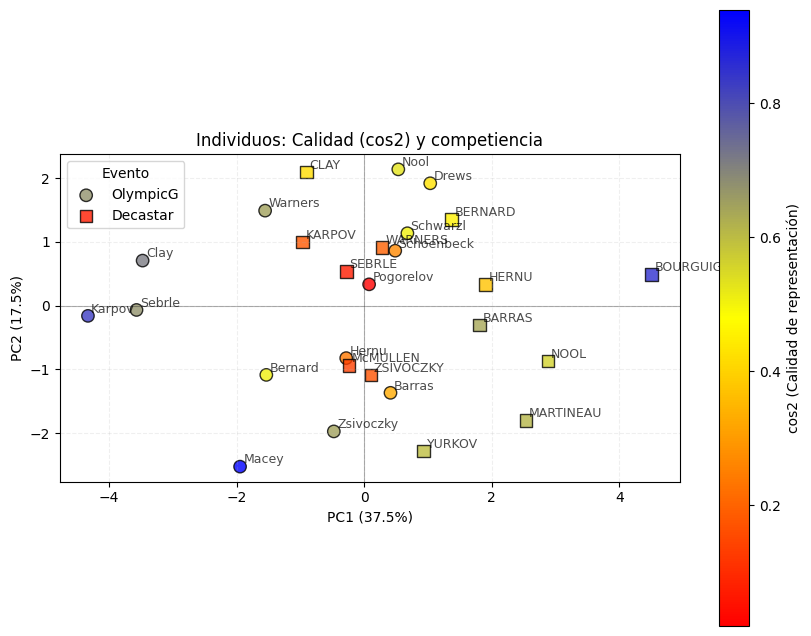

In [22]:
# 1. Preparación de datos y cálculos de cos2
# Recuperamos la columna Competition del dataframe original
competencias = df.iloc[0:27, 12] # Columna 'competition'
coords_ind = pca_features[:, :2]

# Cálculo del cos2 para el color
dist_total_sq = np.sum(pca_features**2, axis=1)
cos2_ind = np.sum(coords_ind**2, axis=1) / dist_total_sq

# Configuración del gráfico
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_aspect('equal', adjustable='box')

# Definir el gradiente
cmap_custom = LinearSegmentedColormap.from_list("fviz_ind", ["red", "yellow", "blue"])
norm = plt.Normalize(vmin=cos2_ind.min(), vmax=cos2_ind.max())

# 3. Graficar por grupos (Diferenciando por marcador/forma)
# Definimos un diccionario de marcadores para cada competencia
marcadores = {'OlympicG': 'o', 'Decastar': 's'} # Círculo y Cuadrado

for comp_nombre, marker in marcadores.items():
    # Filtramos los índices que pertenecen a esta competencia
    mask = (competencias == comp_nombre)

    # Graficamos los puntos de ese grupo
    sc = ax.scatter(coords_ind[mask, 0], coords_ind[mask, 1],
                    c=cos2_ind[mask], cmap=cmap_custom, norm=norm,
                    marker=marker, s=80, edgecolors='black',
                    label=comp_nombre, alpha=0.8)

# Añadimos etiquetas de los nombres de los atletas
for i, txt in enumerate(X.index):
    ax.text(coords_ind[i, 0] + 0.05, coords_ind[i, 1] + 0.05,
            txt, fontsize=9, alpha=0.7)

# 5. Estética, Ejes y Leyendas
ax.axhline(0, color='black', lw=0.8, alpha=0.3)
ax.axvline(0, color='black', lw=0.8, alpha=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Individuos: Calidad (cos2) y competiencia')

ax.legend(title="Evento", loc="upper left")

# Barra de color para el cos2 (calidad)
sm = plt.cm.ScalarMappable(cmap=cmap_custom, norm=norm)
fig.colorbar(sm, ax=ax, label='cos2 (Calidad de representación)')

plt.grid(True, alpha=0.2, linestyle='--')
plt.show()

+ También tenemos otras dos variables numéricas que podríamos querer representar en este nuevo sistema de coordenadas: `rank` y `points`

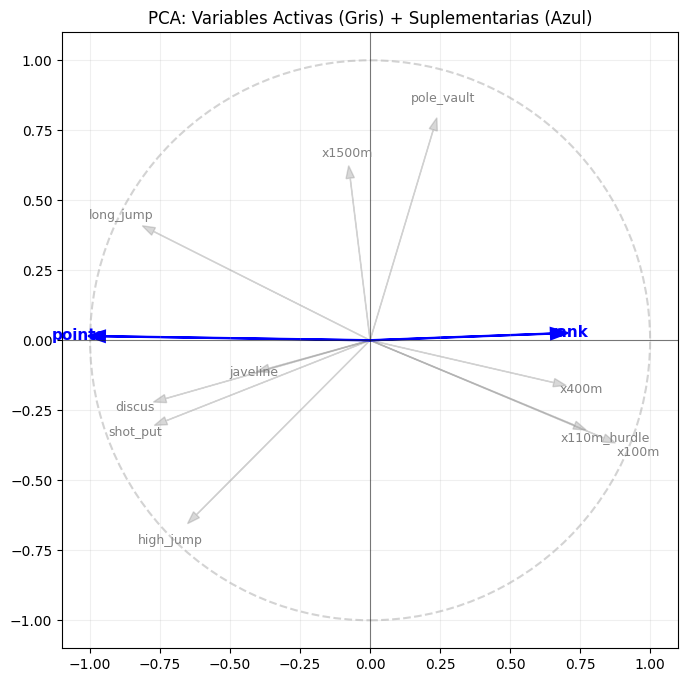

In [23]:
# Obtener los scores de los componentes (coordenadas de los individuos)
# Usamos sólo las primeras dos componentes (Dim1 y Dim2)
scores_df = pd.DataFrame(pca_features[:, :2], columns=['Dim1', 'Dim2'])

# Variables suplementarias: rank y points
X_suple = df[['rank', 'points']].iloc[0:27].reset_index(drop=True)
nombres_originales = df.columns[0:10] # Nombres de las 10 pruebas activas

# Se calcular la correlación
coords_suple = []
for col in X_suple.columns:
    # Correlación con Dim1
    corr_dim1 = np.corrcoef(X_suple[col], scores_df['Dim1'])[0, 1]
    # Correlación con Dim2
    corr_dim2 = np.corrcoef(X_suple[col], scores_df['Dim2'])[0, 1]
    coords_suple.append([corr_dim1, corr_dim2])

coords_suple = np.array(coords_suple)

# Gráfico del Círculo
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# Círculo Unitario
circulo = plt.Circle((0,0), 1, color='lightgray', fill=False, linestyle='--', linewidth=1.5)
ax.add_artist(circulo)

# Se dibujan las variables activas
for i in range(loadings.shape[0]):
    x_act, y_act = loadings[i, 0], loadings[i, 1]
    ax.arrow(0, 0, x_act, y_act, color='gray', alpha=0.3, head_width=0.03)

    # Etiqueta para variables originales
    ax.text(x_act * 1.15, y_act * 1.15, nombres_originales[i],
            color='gray', fontsize=9, ha='center', va='center')

# Se dibujan las variables suplementarias
for i, label in enumerate(X_suple.columns):
    x, y = coords_suple[i, 0], coords_suple[i, 1]

    ax.arrow(0, 0, x, y, color='blue', linestyle='-', linewidth=1.5, head_width=0.04)

    # Etiqueta
    ax.text(x * 1.1, y * 1.1, label, color='blue', fontweight='bold',
            ha='center', va='center', fontsize=11)

# Estética
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.axhline(0, color='black', lw=0.8, alpha=0.5)
ax.axvline(0, color='black', lw=0.8, alpha=0.5)
ax.set_title('PCA: Variables Activas (Gris) + Suplementarias (Azul)')
plt.grid(alpha=0.2)
plt.show()

# Es tu turno

Trabajaremos con un data set que contiene información de varias pizzas de varias cadenas

In [24]:
# La raw URL del CSV en GitHub
url = "https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion17/pizza_dataset.csv"

# Cargar el dataset
df_pizza = pd.read_csv(url)

df_pizza.head()

,brand,id,mois,prot,fat,ash,sodium,carb,cal
0,A,14069,27.82,21.43,44.87,5.11,1.77,0.77,4.93
1,A,14053,28.49,21.26,43.89,5.34,1.79,1.02,4.84
2,A,14025,28.35,19.99,45.78,5.08,1.63,0.80,4.95
3,A,14016,30.55,20.15,43.13,4.79,1.61,1.38,4.74
4,A,14005,30.49,21.28,41.65,4.82,1.64,1.76,4.67


In [25]:
df_pizza.shape

(300, 9)

In [26]:
df_pizza = df_pizza.set_index('id')

In [27]:
df_pizza.head()

,brand,mois,prot,fat,ash,sodium,carb,cal
id,,,,,,,,
14069,A,27.82,21.43,44.87,5.11,1.77,0.77,4.93
14053,A,28.49,21.26,43.89,5.34,1.79,1.02,4.84
14025,A,28.35,19.99,45.78,5.08,1.63,0.80,4.95
14016,A,30.55,20.15,43.13,4.79,1.61,1.38,4.74
14005,A,30.49,21.28,41.65,4.82,1.64,1.76,4.67


In [28]:
df_grafico = pd.read_csv(url)
fig = px.scatter(df_grafico,
                 x = "prot",
                 y = "fat",
                 facet_col = "brand",
                 title = "Proteína vs grasa",
                 template = "plotly_white")

# Ajustar posición de etiquetas para que no tapen el punto
fig.update_traces(textposition = 'top center')

fig.show()

In [29]:
df_grafico = pd.read_csv(url)
fig = px.scatter(df_grafico,
                 x = "prot",
                 y = "sodium",
                 facet_col = "brand",
                 title = "Proteína vs sodio",
                 template = "plotly_white")

# Ajustar posición de etiquetas para que no tapen el punto
fig.update_traces(textposition = 'top center')

fig.show()

In [30]:
# Sólo se considerarán variables numéricas de las características de las pizzas
variables_consideradas = ['mois', 'prot', 'fat', 'ash', 'sodium', 'carb', 'cal']